In [31]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from sklearn.model_selection import train_test_split

In [34]:
df= pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [35]:
df= df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [36]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [37]:
X_train , X_test, y_train, y_test = train_test_split(df.drop('Purchased',axis=1),
                                                     df['Purchased'],
                                                     test_size=0.3,
                                                     random_state=0)
X_train.shape, y_train.shape

((280, 2), (280,))

## StandardScalar

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [40]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [41]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [45]:
X_train_scaled= pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [46]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [47]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## After scalling 
`mean == 0`
`std == 1`

# Effect

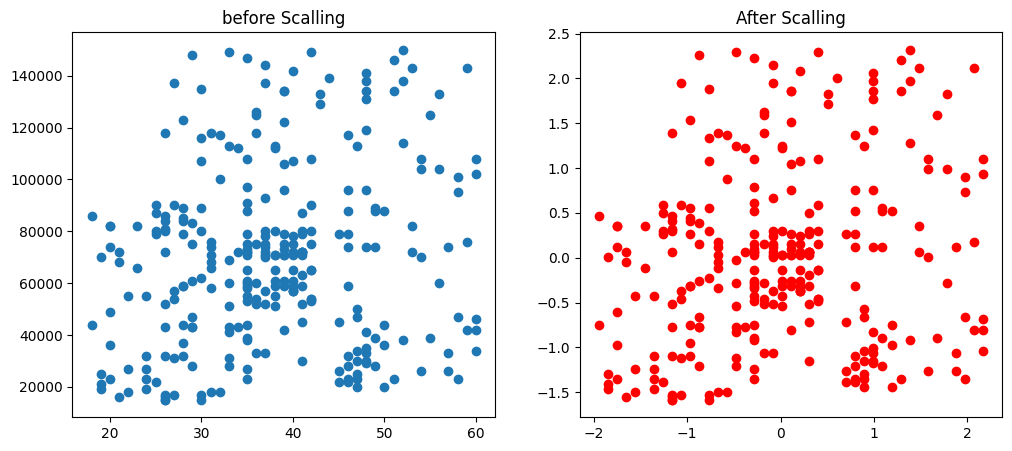

In [48]:
fig, (ax1,ax2)= plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("before Scalling")

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scalling")

plt.show()

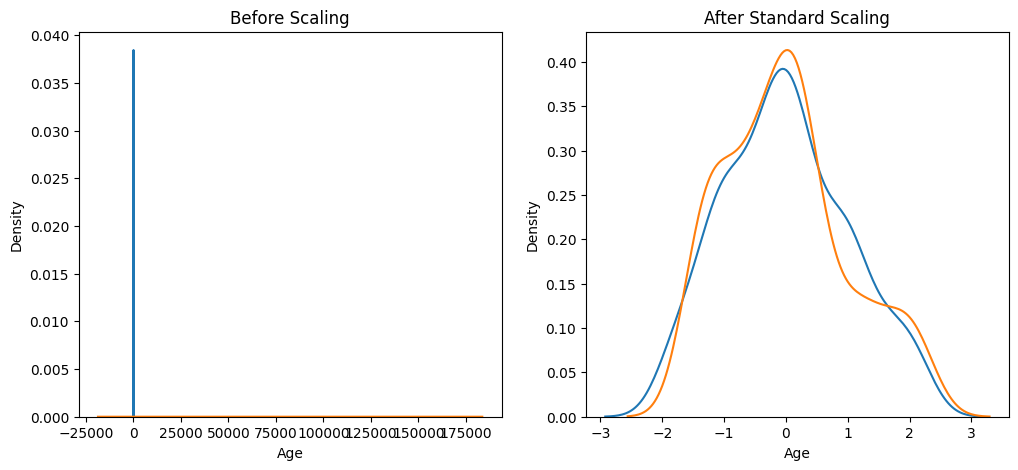

In [49]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Distribution Comparison

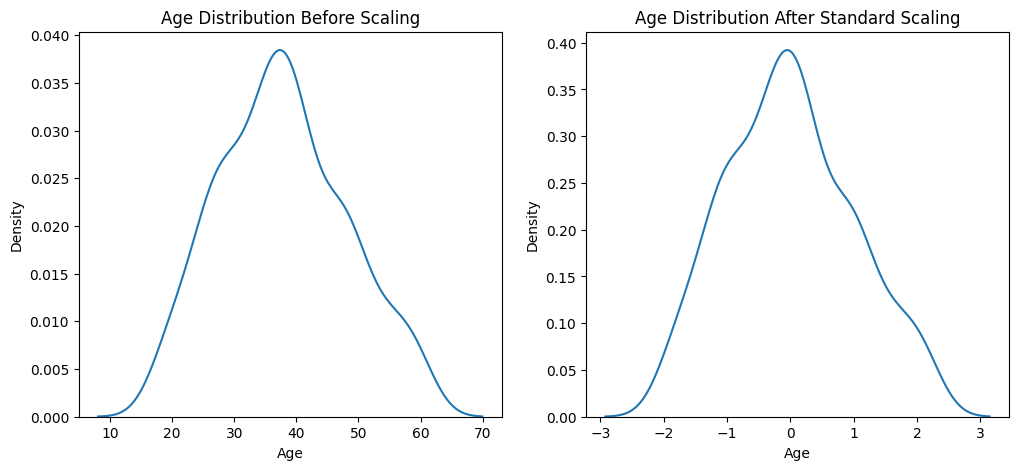

In [50]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

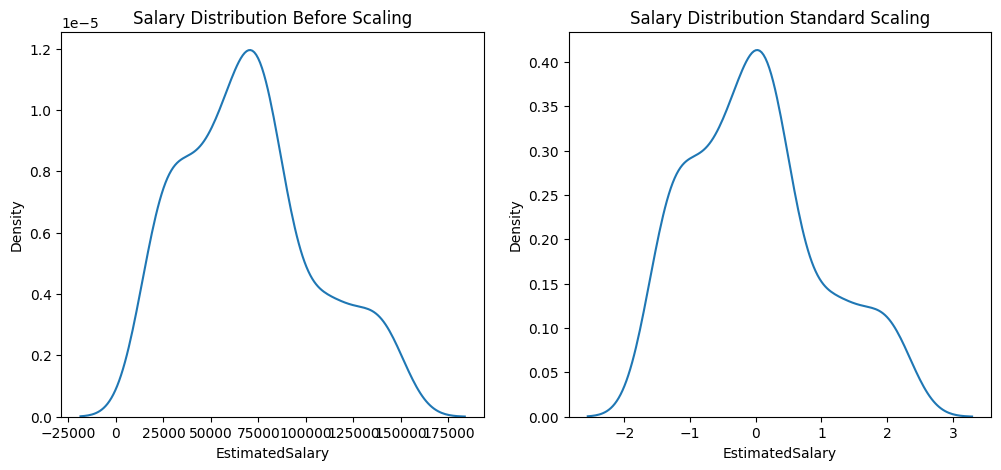

In [51]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

In [52]:
# it Standard scalar does not affect the distribution and shape of data 

## why scaling is important

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
lr= LogisticRegression()
lr_scaled= LogisticRegression()

In [55]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
y_pred=lr.predict(X_test)
y_pred2= lr_scaled.predict(X_test_scaled)

In [57]:
from sklearn.metrics import accuracy_score

In [58]:
print("Actual accuracy: ", accuracy_score(y_test, y_pred))
print("Scaled Accuracy: ",accuracy_score(y_test,y_pred2))

Actual accuracy:  0.875
Scaled Accuracy:  0.8666666666666667


### mostly the accuracy is beeter thatn the actual accuracy score, for some model

### Standardscalling is not necessary for the tree models

# Effect of outliers


In [69]:
df = pd.concat(
    [
        df,
        pd.DataFrame({
            'Age': [5, 90, 95],
            'EstimatedSalary': [1000, 250000, 350000],
            'Purchased': [0, 1, 1]
        })
    ],
    ignore_index=True
)

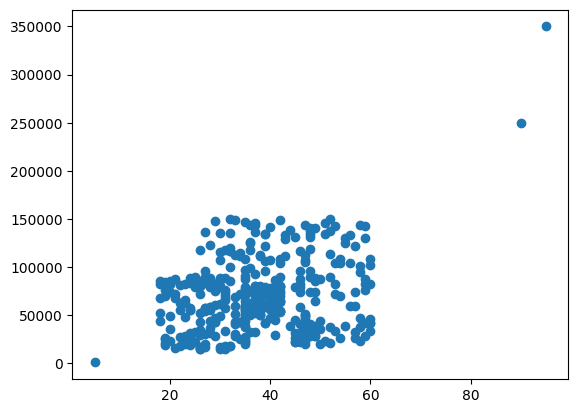

In [70]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [71]:
X_train, X_test, y_train, y_test = train_test_split( df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [74]:
from sklearn.preprocessing import StandardScaler

scalar= StandardScaler()

scaler.fit(X_train)

scaler.transform(X_train)
scaler.transform(X_test)


array([[-2.87398869e-01, -1.33555216e+00],
       [ 3.51481049e-01,  1.66077464e-01],
       [-5.61204548e-01,  1.35604811e+00],
       [-9.26278786e-01,  5.06069078e-01],
       [-1.29135303e+00, -3.15577322e-01],
       [-1.96130309e-01, -1.73914150e-01],
       [-1.10881591e+00,  3.07740636e-01],
       [-2.87398869e-01,  2.20602715e+00],
       [-2.87398869e-01, -2.87244688e-01],
       [ 4.42749609e-01,  1.21438494e+00],
       [-7.43741667e-01, -5.70571033e-01],
       [ 1.99431512e+00, -6.55568936e-01],
       [ 3.51481049e-01,  3.07740636e-01],
       [-1.38262158e+00, -1.73914150e-01],
       [-1.65642726e+00,  4.77736443e-01],
       [ 2.60212489e-01, -2.58912053e-01],
       [ 8.07823847e-01,  2.12102924e+00],
       [-1.83896438e+00, -3.22509775e-02],
       [-1.38262158e+00, -1.16555636e+00],
       [-3.78667428e-01, -7.40566840e-01],
       [-1.83896438e+00, -4.85573129e-01],
       [ 1.08162953e+00, -1.39221743e+00],
       [-1.74769582e+00,  4.49403809e-01],
       [ 1.

In [75]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

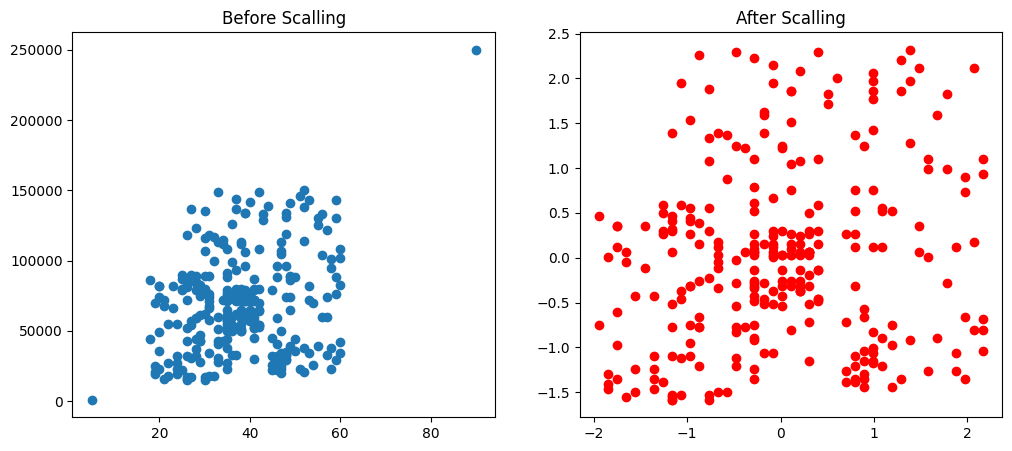

In [77]:
fig, (ax1,ax2) =plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scalling")

ax2.scatter( X_train_scaled["Age"], X_train_scaled["EstimatedSalary"], color='red')
ax2.set_title("After Scalling")
plt.show()